![](../images/logos/KIEPSKIES.jpg)

# **Feature Extraction on Time Series Data**

## Introduction

Imagine you're tracking multiple stock prices over time—Apple, Google, Nvidia, and more. Each stock moves up and down daily, often influenced by other stocks, economic events, and global trends. In multivariate time series analysis, we don’t just examine one stock in isolation; we analyze multiple related data points simultaneously. But with so much data, how do we ensure our models focus on what truly matters?

That’s where feature extraction comes in! Instead of feeding raw, bulky data into our models, we carefully select only the most informative features—those that truly capture patterns and relationships. This not only enhances model accuracy but also prevents overfitting, speeds up computation, and makes interpretation easier.

Since time series data often contains redundant information, feature extraction helps us remove unnecessary noise while preserving essential insights. For example, deep learning techniques can automatically extract features, reducing the need for manual selection. However, these methods can be computationally heavy and sometimes act as a black box, making interpretation difficult.

In our analysis, we’ll work with real stock data from the "Magnificent Seven" (Apple, Google, Nvidia, etc.) using Yahoo Finance. We'll start by visualizing raw stock prices before applying any feature engineering. Since stocks are often interdependent—like how Apple’s price movements might affect Google’s—our goal is to uncover these hidden relationships and make data-driven decisions.

Now, let’s begin by plotting the opening prices of all stocks over time! 🚀📈

In [1]:
# Load all the required libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load all stock CSV files
file_paths = glob.glob("../data/stocks/*.csv")  # Change to your directory
stock_data = {}

for file in file_paths:
    stock_name = file.split("/")[-1].split(".")[0]  # Extract stock name from filename
    df = pd.read_csv(file, parse_dates=['Date'], index_col='Date')
    stock_data[stock_name] = df

In [3]:
file_paths

['../data/stocks/TSLA.csv',
 '../data/stocks/AMZN.csv',
 '../data/stocks/NVDA.csv',
 '../data/stocks/MSFT.csv',
 '../data/stocks/GOOGL.csv',
 '../data/stocks/AAPL.csv',
 '../data/stocks/META.csv']

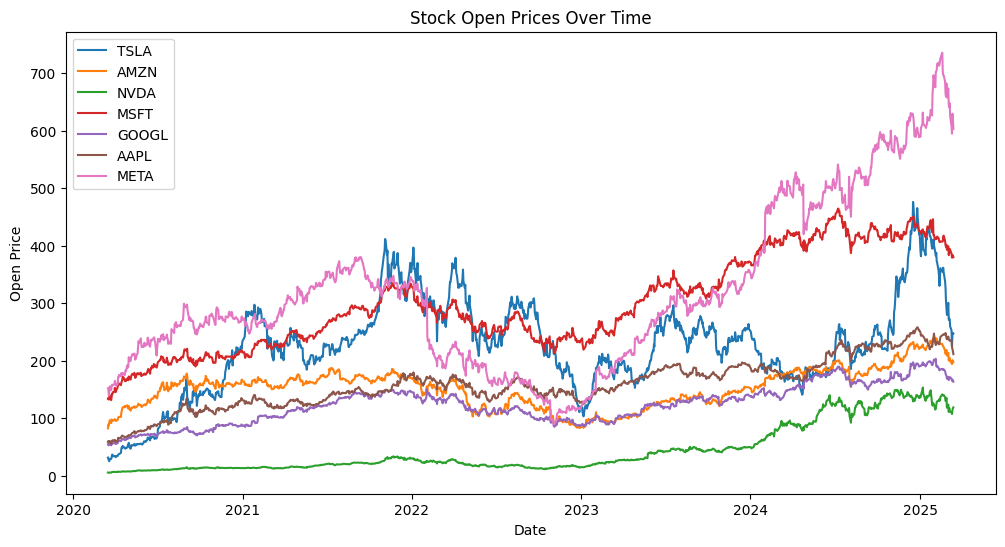

In [4]:
# Plot the Open Prices for all stocks
plt.figure(figsize=(12, 6))

for stock, df in stock_data.items():
    plt.plot(df.index, df["Open"], label=stock)

plt.xlabel("Date")
plt.ylabel("Open Price")
plt.title("Stock Open Prices Over Time")
plt.legend()
plt.show()


This plot provides a clear visual representation of how each stock’s opening price has evolved over the past five years. It will also help us identify trends and correlations before diving into feature extraction.

## Diagnosis 
### 1. **Residuals: Diagnosing Model Performance**

Before we dive into advanced feature extraction techniques, let's take a step back and diagnose how well a simple model fits our NVIDIA stock data. One of the most insightful ways to do this is by analyzing **residuals**.

But what exactly are residuals? 🤔

Residuals represent the **difference between the actual stock price and the predicted price**. If our model were perfect, the residuals would be close to zero across all time points. However, if we notice patterns in the residuals, it suggests that the model is missing important information—perhaps due to missing features or non-linearity in the data.

By plotting the **predicted values** alongside the **residual plot**, we can visually inspect whether our model has **systematic errors**. If residuals exhibit a pattern instead of random scatter, it's a sign that we need to improve our feature extraction techniques.

We will fit a simple Linear Regression model on NVIDIA's stock proces and the visualize the redicted vs actual prices along with the residuals. 

In [5]:
from sklearn.model_selection import train_test_split

# Access the data
nvidia_df = stock_data['NVDA']

# Feature: Using previous day's 'Open' price to predict the next day's price
nvidia_df["Prev_Open"] = nvidia_df["Open"].shift(1)
nvidia_df = nvidia_df.dropna()  # Drop the first row since it has NaN

# Define features and target variable
X = nvidia_df[["Prev_Open"]]
y = nvidia_df["Open"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


Fit a linear regression model, make predictions and calculate residuals

In [6]:
from sklearn.linear_model import LinearRegression

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Compute residuals
residuals = y_test - y_pred

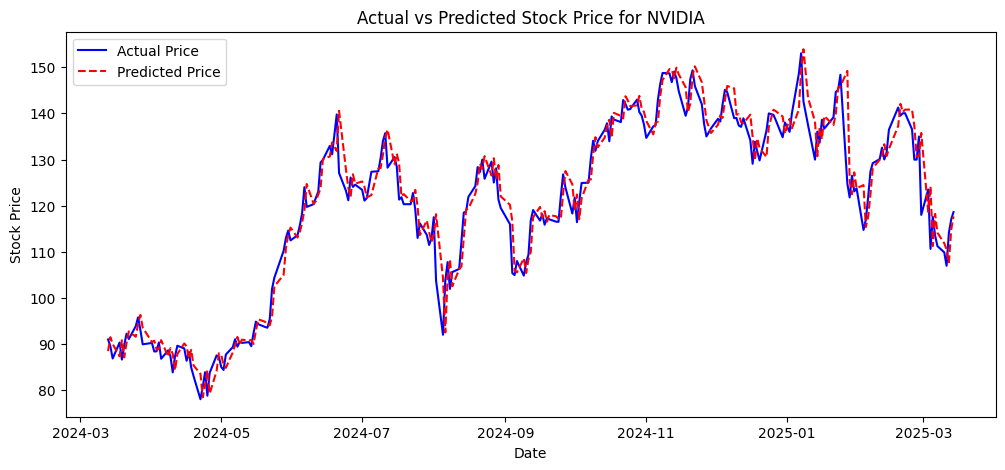

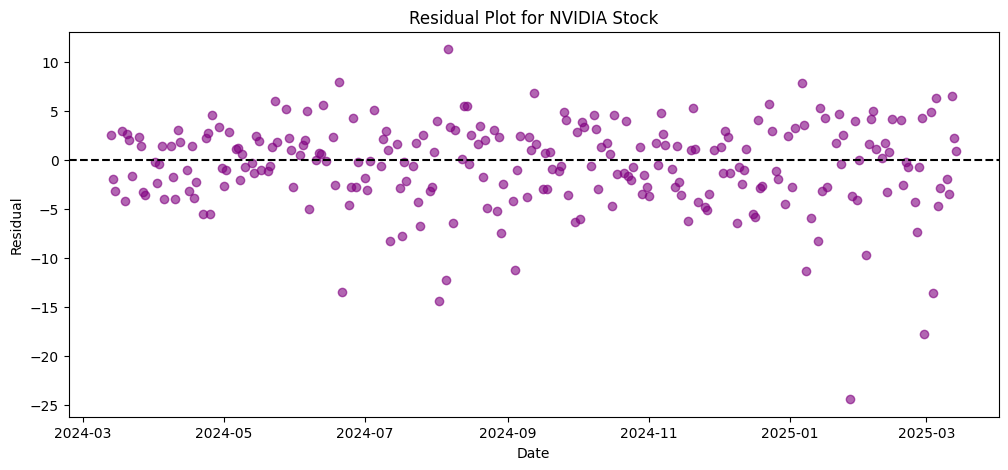

In [7]:
# Plot predicted vs actual values
plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test, label="Actual Price", color='blue')
plt.plot(y_test.index, y_pred, label="Predicted Price", color='red', linestyle="dashed")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("Actual vs Predicted Stock Price for NVIDIA")
plt.legend()
plt.show()

# Plot residuals
plt.figure(figsize=(12, 5))
plt.scatter(y_test.index, residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='black', linestyle="dashed")  # Reference line at zero
plt.xlabel("Date")
plt.ylabel("Residual")
plt.title("Residual Plot for NVIDIA Stock")
plt.show()

Here is what to look when plotting residuals;

- If the residuals show a clear pattern (e.g., trending up or down), it indicates that our linear model is missing important features or that stock prices don’t follow a simple linear trend. -- In our case there is no clear pattern therefore our model is good so far.
- If the residuals are randomly scattered, it suggests that the model’s errors are unbiased, which is a good sign. -- In our case, the residuals are randomly scattered which is a sign of a good-performing model.

By improving feature selection, adding new features (like trading volume, volatility, or moving averages), or using more complex models, we can reduce residual errors and improve prediction accuracy.

### 2. **Correlation Heatmap for Statistical Features: Identifying Redundant Features**

When dealing with multivariate time series data, not all features contribute equally to the model’s performance. Some features may be highly correlated, meaning they provide similar information. A correlation heatmap helps us identify and remove redundant features to improve model efficiency and reduce overfitting.

<span style="color: #00008B;">**Why Use a Correlation Map?**</span>

- **Eliminates redundancy:** If two features have a correlation above 0.7 (or 70%), they convey almost the same information. In such cases, we can drop one feature to simplify the model without losing important insight
- **Feature selection:** The correlation map helps us pick the most informative features and remove those that are weakly related to the target variable.
- **Improves interpretability:** With fewer redundant features, the model is easier to analyze and debug.

Lets calculate statistical features for TESLA stock data and visualize the correlations using a heatmap.

In [8]:
# Access the data
tesla_df = stock_data['TSLA']

In [9]:
# Calculate statistical features
stats_df = pd.DataFrame()
stats_df["Mean"] = tesla_df["Open"].rolling(window=7).mean()  # 7-day moving average (mean)
stats_df["Median"] = tesla_df["Open"].rolling(window=7).median()  # 7-day median
stats_df["Std Dev"] = tesla_df["Open"].rolling(window=7).std()  # 7-day standard deviation
stats_df["Min"] = tesla_df["Open"].rolling(window=7).min()  # 7-day minimum price
stats_df["Max"] = tesla_df["Open"].rolling(window=7).max()  # 7-day maximum price
stats_df["Price Change"] = tesla_df["Open"].diff()  # Daily price change
stats_df = stats_df.dropna()  # Drop NaN values

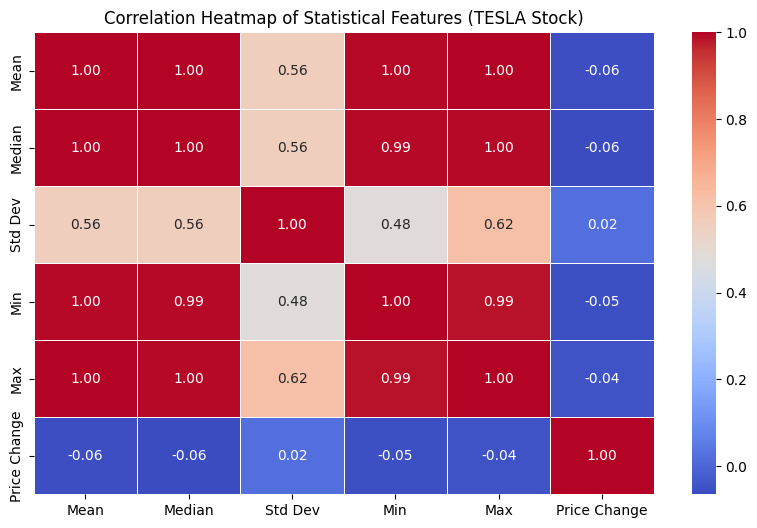

In [10]:
# Compute correlation matrix
corr_matrix = stats_df.corr()

# Plot the correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5, fmt=".2f")
plt.title("Correlation Heatmap of Statistical Features (TESLA Stock)")
plt.show()

Here is what to consider; 

- High correlation (above 0.7) between features means one of them can be removed without losing much information. - In our case here, we will either Max, Mean and Minimum since they are perfectly correlated.
- Low correlation indicates independent features, which may be valuable in predictive modeling. For instance Price Change has a low correlation with most of the features.

Features like mean and median are often highly correlated, so we may choose just one for modeling.

### 3. **Machine Learning-Based Diagnostics for Feature Selection**

While a correlation heatmap helps identify redundant features, it only captures linear relationships between features. However, real-world data often has complex and nonlinear relationships that a simple correlation analysis might miss.

To address this, we can use machine learning-based feature selection to:

- Identify which features contribute the most to predictions.
- Remove features with low importance that do not significantly impact the target variable.
- Capture both linear and nonlinear dependencies among features.

A common technique for feature importance analysis is using a tree-based model such as Random Forest or XGBoost, which naturally ranks features based on how much they contribute to prediction accuracy.

Lets fit a Random Forest model to Apple’s stock closing prices and visualizes feature importance using a bar plot.

In [11]:
# Access the data
apple_df = stock_data['AAPL']

In [13]:
# Feature Engineering (Creating Statistical Features)
apple_df["Mean"] = apple_df["Close"].rolling(window=7).mean()
apple_df["Median"] = apple_df["Close"].rolling(window=7).median()
apple_df["Std Dev"] = apple_df["Close"].rolling(window=7).std()
apple_df["Min"] = apple_df["Close"].rolling(window=7).min()
apple_df["Max"] = apple_df["Close"].rolling(window=7).max()
apple_df["Price Change"] = apple_df["Close"].diff()
apple_df = apple_df.dropna()  # Drop NaN values

In [14]:
# Define features and target variable
X = apple_df.drop(columns=["Close"])  # Feature set
y = apple_df["Close"]  # Target variable (closing price)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Get feature importance
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)

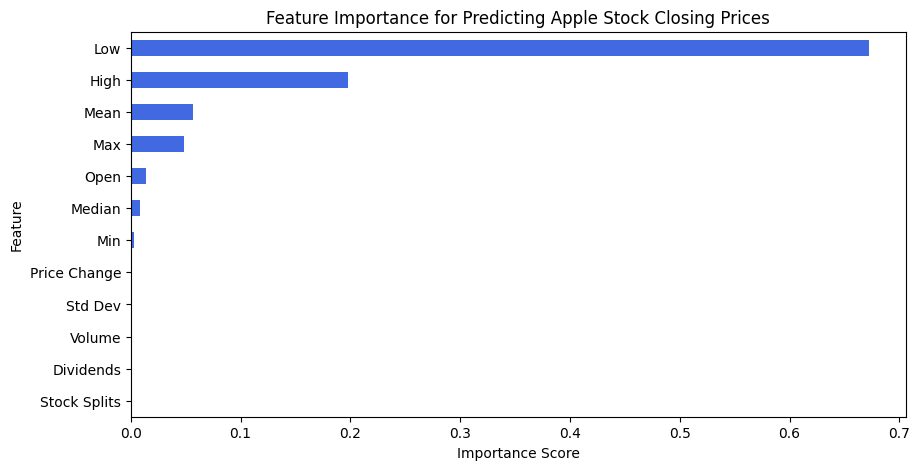

In [16]:
# Plot feature importance
plt.figure(figsize=(10, 5))
feature_importance.sort_values(ascending=True).plot(kind="barh", color="royalblue")
plt.title("Feature Importance for Predicting Apple Stock Closing Prices")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

---------------------------------**table for damages**------------------------------------------

## Directions
### 1. **Autocorrelation and Lag Feature Extraction**

### 2. **Differencing**

Time series data often contains trends and seasonality, making it non-stationary (i.e., its statistical properties change over time). Differencing is a technique used to:
- Remove trends & seasonality while preserving essential patterns.
- Improve stationarity, which is necessary for models like ARIMA.
- Enhance predictive performance by ensuring that model assumptions hold.

Before applying differencing, we need to check if the data is stationary using the Augmented Dickey-Fuller (ADF) test.

Differencing is done by subtracting the previous value from the current value:
$$\text{Difference} = X_t - X_{t-1}$$

Lets perform differencing on Apple, Google and NVIDIA stocks and plot them against time. 

In [24]:
# Load and access the data 
google_df = stock_data["GOOGL"] # we had accessed apple and nvidia stocks data before

# Apply first-order differencing to remove trends
apple_df["Diff_Close"] = apple_df["Close"].diff()
google_df["Diff_Close"] = google_df["Close"].diff()
nvidia_df["Diff_Close"] = nvidia_df["Close"].diff()

/tmp/ipykernel_25447/3075892615.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  apple_df["Diff_Close"] = apple_df["Close"].diff()
/tmp/ipykernel_25447/3075892615.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nvidia_df["Diff_Close"] = nvidia_df["Close"].diff()


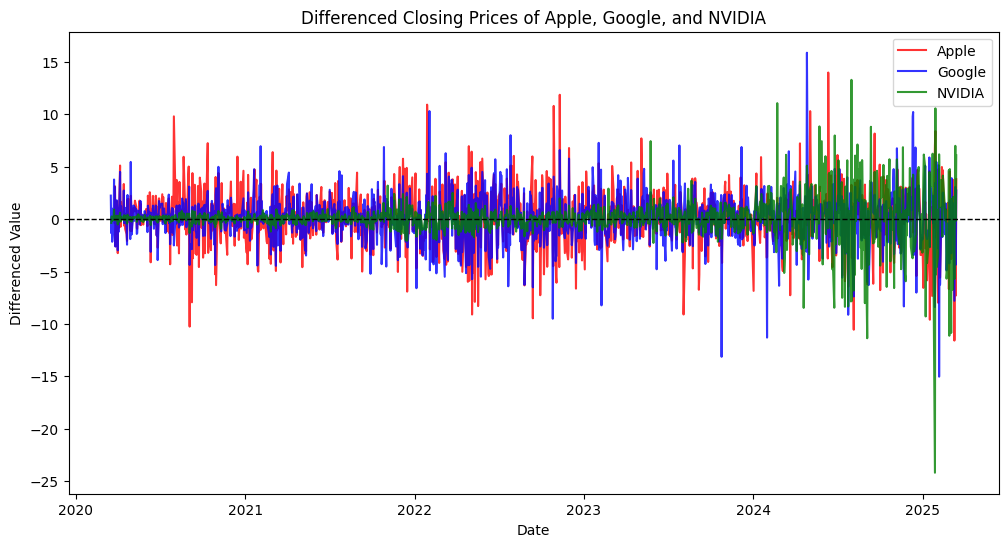

In [25]:
# Plot differenced values
plt.figure(figsize=(12, 6))
plt.plot(apple_df.index, apple_df["Diff_Close"], label="Apple", color="red", alpha=0.8)
plt.plot(google_df.index, google_df["Diff_Close"], label="Google", color="blue", alpha=0.8)
plt.plot(nvidia_df.index, nvidia_df["Diff_Close"], label="NVIDIA", color="green", alpha=0.8)
plt.axhline(y=0, color="black", linestyle="--", linewidth=1)
plt.title("Differenced Closing Prices of Apple, Google, and NVIDIA")
plt.xlabel("Date")
plt.ylabel("Differenced Value")
plt.legend()
plt.show()

Here is what you should take note of;

- Differencing helps in stabilizing the mean of time series data, making it easier to model.
- If the differenced series is still non-stationary, higher-order differencing (second-order differencing) may be needed.
- ADF Test should be performed to confirm stationarity. If the test p-value is less than 0.05, the series is stationary.

3. **Cross-Correlation**

<span style="color: #00008B;">**What is Cross-Correlation?**</span>

Cross-correlation is a statistical technique used to measure the relationship between two time series while considering time lags. Unlike standard correlation, which captures the overall linear relationship between two variables, cross-correlation helps identify how one variable influences another over time.

Lets put this in layman's term; we will consider Apple and Google as two friends. Lets imagine you are tracking them, who often go running together. If Apple starts running faster, Google might speed up a few minutes later. Cross-correlation helps us figure out if changes in Apple's speed influence Google's speed after a delay—just like how one stock's movement might affect another after some time!

Here is why cross-correlation important; 

- Predicting Future Movements – If Apple stock moves today and Google stock reacts a few days later, we can use this pattern for forecasting.
- Understanding Market Dependencies – Helps in identifying relationships between stocks, commodities, or economic indicators.
- Feature Engineering for Machine Learning – Selecting lagged variables that improve predictive models.

In simple terms, think of cross-correlation as a time-traveling detective tool for stock prices! Instead of just seeing how Apple and Google move together, we want to know:

- Does Apple’s price today affect Google’s price tomorrow?
- Is there a delay (lag) between their movements?
- Can we use this insight to make better investment decisions?

Cross-correlation helps us measure these relationships at different time lags and see if one stock is "leading" the other! 🚀📈

Lets put this into practice!

In [26]:
# Extract closing prices
apple_close = apple_df["Close"]
google_close = google_df["Close"]

# Define function for cross-correlation
def cross_correlation(series1, series2, max_lag=30):
    lags = np.arange(-max_lag, max_lag + 1)
    correlations = [series1.corr(series2.shift(lag)) for lag in lags]
    return lags, correlations

# Compute cross-correlation
lags, correlations = cross_correlation(apple_close, google_close)

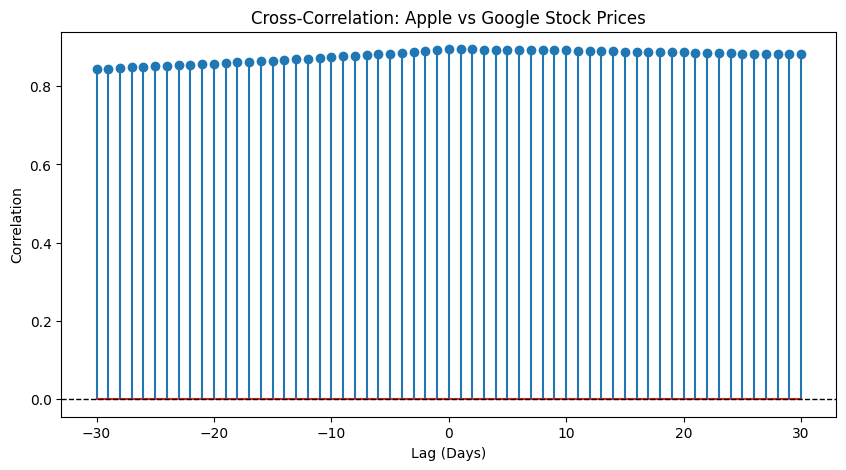

In [28]:
# Plot cross-correlation
plt.figure(figsize=(10, 5))
plt.stem(lags, correlations)#, use_line_collection=True)
plt.axhline(y=0, color="black", linestyle="--", linewidth=1)
plt.title("Cross-Correlation: Apple vs Google Stock Prices")
plt.xlabel("Lag (Days)")
plt.ylabel("Correlation")
plt.show()

Here is what to consider when interpretting the plots; 

- Positive correlation at a certain lag → Apple’s price change predicts Google’s movement after that lag.
- Negative correlation at a certain lag → If Apple rises, Google tends to fall after that lag.
- Zero correlation at most lags → No strong relationship at those time shifts.

Cross-correlation helps uncover hidden relationships in time series data that simple correlation misses. By identifying lagged dependencies, we can make better investment decisions, feature selections, and predictive models! 🚀📈

Would you like to extend th

### 4. Time-Based Feature Extraction: Rolling Mean & Rolling Standard Deviation

When analyzing time series data, smoothing techniques help in understanding long-term trends while filtering out short-term fluctuations. Two commonly used techniques are:

- **Rolling Mean (Moving Average)** – Helps in highlighting underlying trends by averaging stock prices over a fixed window (e.g., 30 days). It reduces noise and makes trends more visible.
- **Rolling Standard Deviation** – Measures volatility over time, complementing the rolling mean by showing how much prices fluctuate within the same window.

Lets put this into practice!

In [30]:
# Load the Microsoft data
msft_df = stock_data["MSFT"]


# Compute 30-day Rolling Mean and Rolling Standard Deviation
msft_df["Rolling Mean"] = msft_df["Close"].rolling(window=30).mean()
msft_df["Rolling Std"] = msft_df["Close"].rolling(window=30).std()

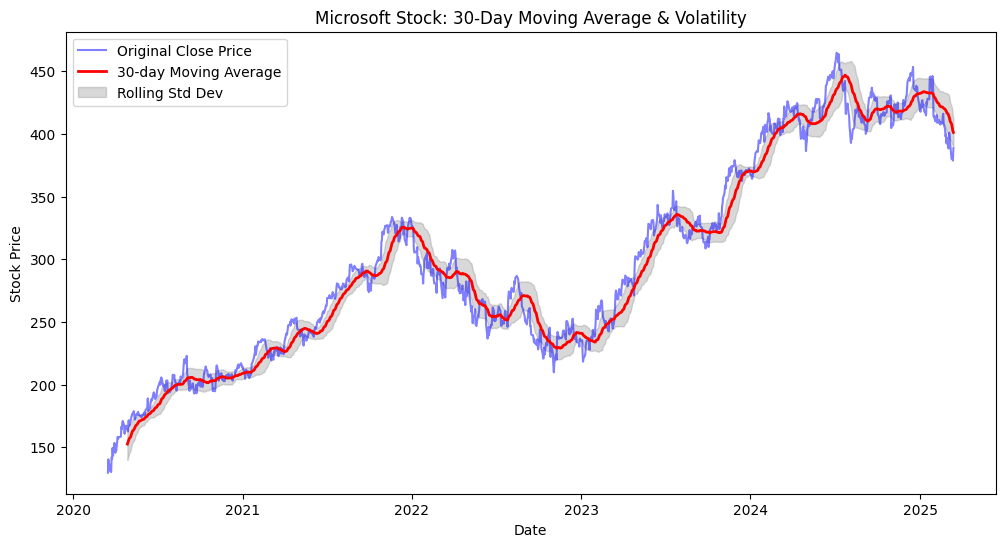

In [31]:
# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(msft_df.index, msft_df["Close"], label="Original Close Price", color="blue", alpha=0.5)
plt.plot(msft_df.index, msft_df["Rolling Mean"], label="30-day Moving Average", color="red", linewidth=2)
plt.fill_between(msft_df.index, msft_df["Rolling Mean"] - msft_df["Rolling Std"], 
                 msft_df["Rolling Mean"] + msft_df["Rolling Std"], color='gray', alpha=0.3, label="Rolling Std Dev")

plt.title("Microsoft Stock: 30-Day Moving Average & Volatility")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

- The red line (Rolling Mean) smooths out short-term fluctuations, showing the overall trend.
- The shaded region (Rolling Standard Deviation) highlights periods of high & low volatility.
- A widening shaded area indicates an increase in stock price fluctuations (market uncertainty).

These time-based features are crucial for feature engineering in predictive models, volatility analysis, and trend forecasting! 🚀📈

5. ### **Exponential Moving Average (EMA)**

While Simple Moving Averages (SMA) treat all past values equally, the Exponential Moving Average (EMA) gives more weight to recent values. This makes EMA more responsive to sudden price changes, making it better suited for trading strategies and forecasting.

<span style="color: #00008B;">**Why Use EMA?**</span>

- More Weight on Recent Prices → Captures trends faster than SMA.
- Reduces Lag → Helps in detecting reversals earlier.
- Used in Technical Analysis → Popular in stock market predictions

Lets put this into practice!

In [32]:
# Compute 30-day Exponential Moving Average
msft_df["EMA_30"] = msft_df["Close"].ewm(span=30, adjust=False).mean()

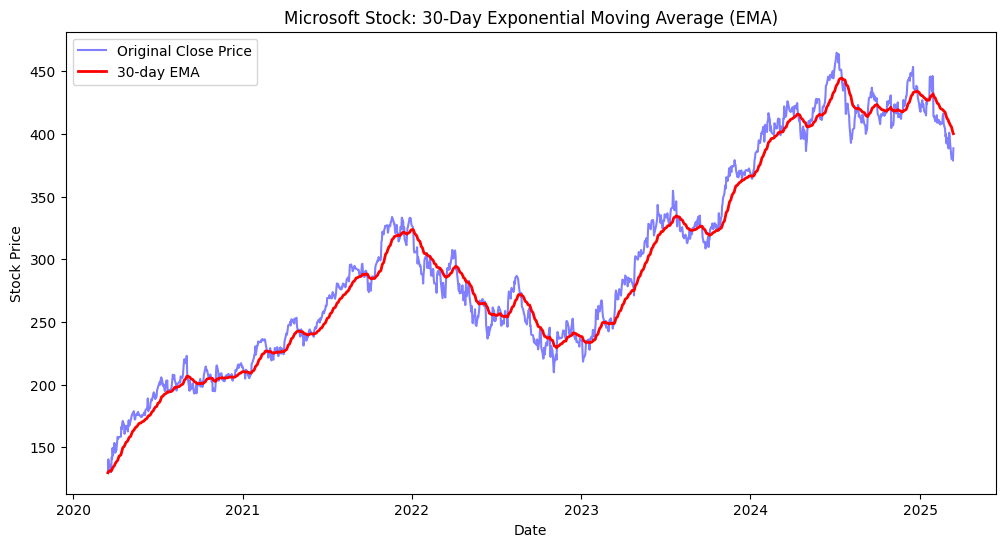

In [33]:
# Plot Original Prices and EMA
plt.figure(figsize=(12, 6))
plt.plot(msft_df.index, msft_df["Close"], label="Original Close Price", color="blue", alpha=0.5)
plt.plot(msft_df.index, msft_df["EMA_30"], label="30-day EMA", color="red", linewidth=2)

plt.title("Microsoft Stock: 30-Day Exponential Moving Average (EMA)")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

- The red line (EMA) closely follows the stock price but smooths out minor fluctuations.
- More responsive than SMA → It adjusts quickly to price movements.
- Useful for trend identification → If prices are consistently above EMA, the stock is in an uptrend

### 6. **Shape-Based Feature Extraction**

<span style="color: #00008B;">**Why Shape-Based Features?**</span>

In stock market data, the shape of the price movement helps capture volatility and trend reversals. Instead of just analyzing the price directly, peaks and valleys provide a structured way to extract meaningful features for better forecasting.

Here are the Key Features Extracted; 

- Number of Peaks & Valleys → Identifies frequency of events and volatility shifts.
- Peak-to-Peak Difference → Captures trend strength.
- Peak-to-Valley Difference → Measures drawdowns and corrections.
- Mean Adjusted Close Price → Centered price movement.
- Standard Deviation of Adjusted Close → Highlights volatility

Into action!

In [41]:
from scipy.signal import find_peaks

# Compute mean adjusted close price
mean_close = apple_df["Close"].mean()

# Compute standard deviation of  close price
std_close = apple_df["Close"].std()

# Find peaks and valleys
peaks, _ = find_peaks(apple_df["Close"])
valleys, _ = find_peaks(-apple_df["Close"])  # Inverting to find valleys

# Compute Peak-to-Peak Difference
peak_to_peak_diff = apple_df["Close"].iloc[peaks].max() - apple_df["Close"].iloc[peaks].min()

# Compute Peak-to-Valley Difference
peak_to_valley_diff = apple_df["Close"].iloc[peaks].max() - apple_df["Close"].iloc[valleys].min()

# Summary
print(f"Mean Close Price: {mean_close:.2f}")
print(f"Standard Deviation of Close Price: {std_close:.2f}")
print(f"Number of Peaks: {len(peaks)}")
print(f"Number of Valleys: {len(valleys)}")
print(f"Peak-to-Peak Difference: {peak_to_peak_diff:.2f}")
print(f"Peak-to-Valley Difference: {peak_to_valley_diff:.2f}")


Mean Close Price: 158.97
Standard Deviation of Close Price: 41.42
Number of Peaks: 317
Number of Valleys: 318
Peak-to-Peak Difference: 199.30
Peak-to-Valley Difference: 200.27


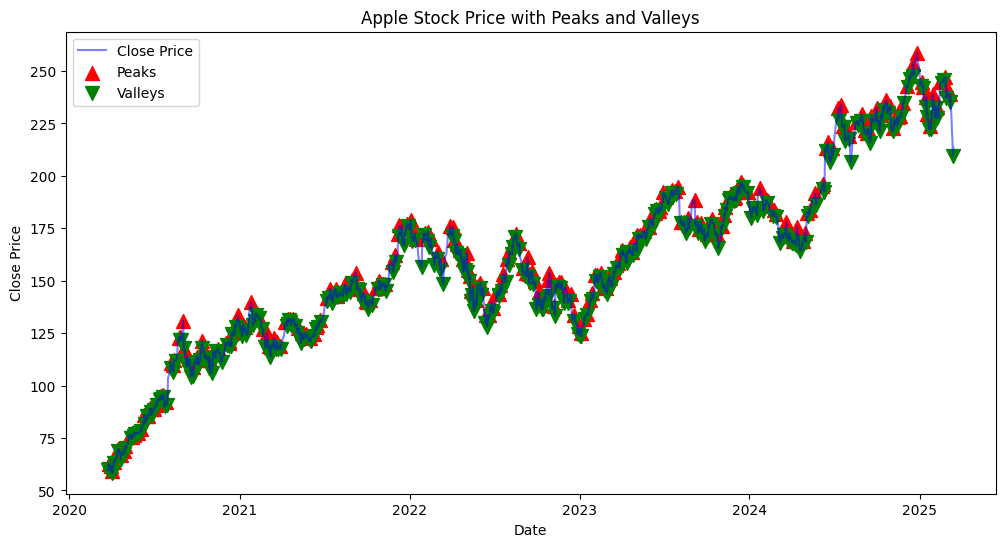

In [42]:
plt.figure(figsize=(12, 6))

# Plot Close Price
plt.plot(apple_df.index, apple_df["Close"], label="Close Price", color="blue", alpha=0.5)

# Mark Peaks
plt.scatter(apple_df.index[peaks], apple_df["Close"].iloc[peaks], color="red", label="Peaks", marker="^", s=100)

# Mark Valleys
plt.scatter(apple_df.index[valleys], apple_df["Close"].iloc[valleys], color="green", label="Valleys", marker="v", s=100)

plt.title("Apple Stock Price with Peaks and Valleys")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()


- Peaks (Red Dots): Identify local highs (potential resistance levels)
- Valleys (Green Dots): Indicate local lows (potential support levels)
- Volatility Detection: A higher number of peaks & valleys suggests increased market fluctuations